<a href="https://colab.research.google.com/github/SarveshD7/GANs-Fashion-Outfit-Generator/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Installing all the dependencies***

In [1]:
! pip install tensorflow tensorflow-gpu matplotlib tensorflow-datasets ipywidgets

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [58 lines of output]
      Traceback (most recent call last):
        File "/tmp/pip-build-env-6y45tixm/overlay/lib/python3.12/site-packages/setuptools/_vendor/packaging/requirements.py", line 36, in __init__
          parsed = _parse_requirement(requirement_string)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "/tmp/pip-build-env-6y45tixm/overlay/lib/python3.12/site-packages/setuptools/_vendor/packaging/_parser.py", line 62, in parse_requirement
          return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "/tmp/pip-build-env-6y45tixm/o

***Importing tensorflow and limiting the virtual RAM growth***


In [23]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)
  

***Importing other dependencies***

In [24]:
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

***Getting the dataset***


In [25]:
ds = tfds.load('fashion_mnist', split='train')


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/victon/tensorflow_datasets/fashion_mnist/incomplete.V1OILK_3.0.1/fashion_mnist-train.tfrecord*…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/victon/tensorflow_datasets/fashion_mnist/incomplete.V1OILK_3.0.1/fashion_mnist-test.tfrecord*.…

Dataset fashion_mnist downloaded and prepared to /home/victon/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


***Visualizing the data***

In [26]:
import numpy as np # For some data transform

In [27]:
# Setup connection aka iterator
dataIterator = ds.as_numpy_iterator()

In [28]:
# Getting data out of pipeline
dataIterator.next()

2025-09-04 07:05:01.508933: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


{'image': array([[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 18],
         [ 77],
         [227],
         [227],
         [208],
         [210],
         [225],
         [216],
         [ 85],
         [ 32],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 61],
         [100],
         [ 97],
         [ 80],
         [ 57],
         [117],
         [227],
         [238],
         [115],
         [ 49],
         [ 78],
         [106],
         [108],
         [ 71],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         

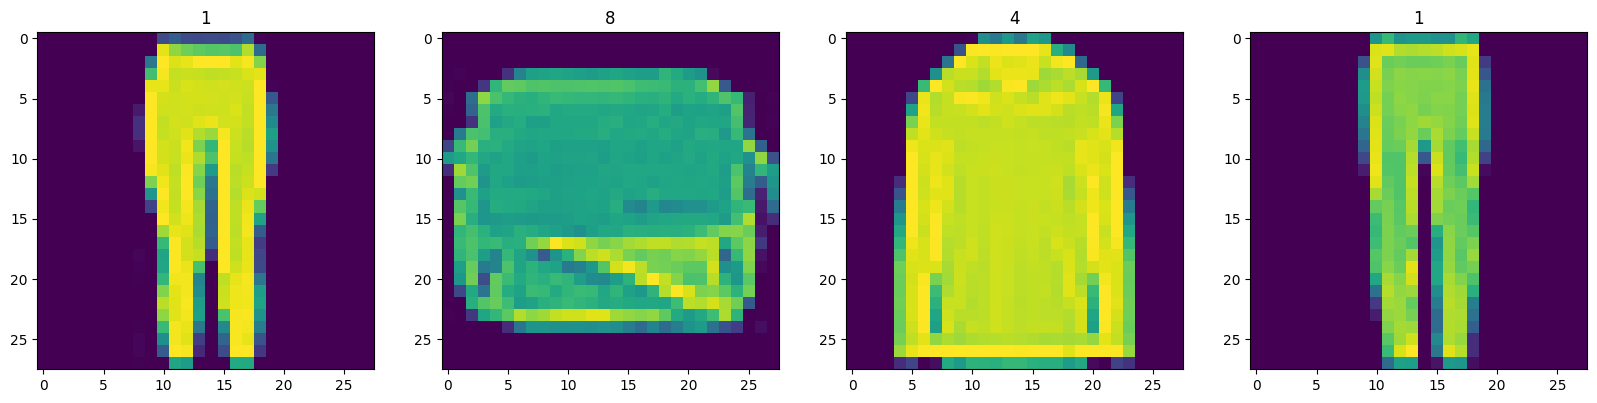

In [29]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx in range(4):
  # Grabbing the image and label
  batch = dataIterator.next()
  # Plot the image using a specific subplot
  ax[idx].imshow(np.squeeze(batch['image']))
  # Appending the image label as plot title
  ax[idx].title.set_text(batch['label'])

***Some data preprocessing***

In [30]:
# Scaling and returning the images only
def scale_images(data):
  image = data['image']
  return image / 255
  

In [31]:
ds = tfds.load('fashion_mnist', split='train')
# Running the images through the scale_images preprocessing step
ds = ds.map(scale_images)
# caching the dataset for that batch
ds = ds.cache()
# Shuffling the dataset
ds = ds.shuffle(60000)
# Batch into 128 images per sample
ds = ds.batch(128)
# Prefetching reduces the likelihood of bottlenecking
ds = ds.prefetch(64)




In [32]:
ds.as_numpy_iterator().next().shape # 128 images of size 28, 28, 1

(128, 28, 28, 1)

***Building the Neural Network***

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Reshape, LeakyReLU, Dropout, UpSampling2D

Building the Generator

In [34]:
def build_generator():
  model = Sequential()

  # Takes in random values and reshapes it to 7x7x128
  # Beginnings ofa generated image  
  model.add(Dense(7*7*128, input_dim = 128))
  model.add(LeakyReLU(0.2))
  model.add(Reshape((7, 7, 128)))

  # Upsampling block 1
  model.add(UpSampling2D())
  model.add(Conv2D(128, 5, padding='same'))
  model.add(LeakyReLU(0.2))

  # Upsampling block 2
  model.add(UpSampling2D())
  model.add(Conv2D(128, 5, padding='same'))
  model.add(LeakyReLU(0.2))

  # Convolutional block 1
  model.add(Conv2D(128, 4, padding='same'))
  model.add(LeakyReLU(0.2))

   # Convolutional block 2
  model.add(Conv2D(128, 4, padding='same'))
  model.add(LeakyReLU(0.2))

  # Final Conv layer to get to one channel
  model.add(Conv2D(1,4,padding='same', activation='sigmoid'))


  return model


In [35]:
generator = build_generator()

/home/victon/proj/fashionGan/ipo/.huk/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,155,137 (8.22 MB)

 Trainable params: 2,155,137 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
img  = generator.predict(np.random.randn(4, 128, 1))
# randn generates a set of random nos with normal distribution
img.shape


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


(4, 28, 28, 1)

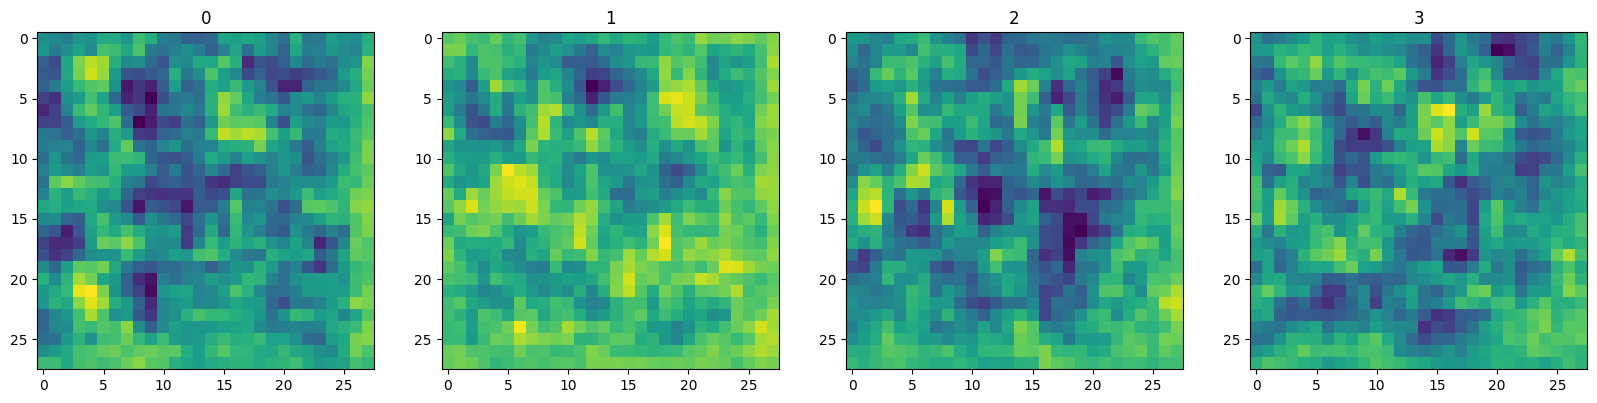

In [38]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img  in enumerate(img):
  ax[idx].imshow(np.squeeze(img))
  ax[idx].title.set_text(idx)

***Build Discriminator***

In [39]:
def build_discriminator():
  model = Sequential()

  # First Conv Block
  model.add(Conv2D(32, 5, input_shape=(28, 28, 1)))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

   # Second Conv Block
  model.add(Conv2D(64, 5))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

 # Third Conv Block
  model.add(Conv2D(128, 5))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

 # Fourth Conv Block
  model.add(Conv2D(256, 5))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

 # Fourth Conv Block
  model.add(Conv2D(256, 5))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

  # Flatten and then pass through Dense Layer
  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1, activation='sigmoid'))
  
  return model


In [40]:
discriminator = build_discriminator()

/home/victon/proj/fashionGan/ipo/.huk/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,731,521 (10.42 MB)

 Trainable params: 2,731,521 (10.42 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
img.shape

(28, 28, 1)

In [43]:
discriminator.predict(np.expand_dims(img,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


array([[0.49850914]], dtype=float32)

***Constructing Training Loops***

***Setting up Losses and Optimizers***

In [44]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy


In [45]:
g_opt = Adam(learning_rate=0.0001)
d_opt = Adam(learning_rate=0.00001)
g_loss = BinaryCrossentropy()
d_loss = BinaryCrossentropy()

In [46]:
from tensorflow.keras.models import Model


In [47]:
class FashionGAN(Model):
  # passing the generator, discriminator, any positional or keyboard arguments
  def __init__(self, generator, discriminator, *args, **kwargs):
    super().__init__(*args, **kwargs)

    self.generator = generator
    self.discriminator = discriminator
    pass

  def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs):
    super().compile(*args, **kwargs)

    self.g_opt = g_opt
    self.d_opt = d_opt
    self.g_loss = g_loss
    self.d_loss = d_loss
    pass 

  def train_step(self, batch):
    # Getting the data
    real_images = batch
    fake_images = self.generator(tf.random.normal((128, 128, 1)), training=False)

    # Training the discriminator
    with tf.GradientTape() as d_tape:
        # To start calculating the gradients
      # -- Pass the real and fake images to the discriminator model
      yhat_real = self.discriminator(real_images, training=True)
      # Training = True makes the dropout layers run else they won't run
      yhat_fake = self.discriminator(fake_images, training=True)
      yhat_realfake = tf.concat([yhat_real, yhat_fake], axis=0)

    # -- Create labels for real and fake images
      y_realfake = tf.concat([tf.zeros_like(yhat_real), tf.ones_like(yhat_fake)], axis=0)
    # -- Add sonme noise to the outputs
      noise_real = 0.15*tf.random.uniform(tf.shape(yhat_real))
      noise_fake = -0.15*tf.random.uniform(tf.shape(yhat_fake))
      y_realfake += tf.concat([noise_real, noise_fake], axis=0)

    # -- Calculate loss BINARY CROSSENTROPY 
      total_d_loss = self.d_loss(y_realfake, yhat_realfake)

    # -- Apply backpropagation 
    dgrad = d_tape.gradient(total_d_loss, self.discriminator.trainable_variables)
    self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables))

    # Train the generator
    with tf.GradientTape() as g_tape:
      # Generate some new images
      gen_images = self.generator(tf.random.normal((128, 128, 1)), training=True)

      # Create the predicted labels
      predicted_labels = self.discriminator(gen_images, training = False)

      # Calculate loss
      total_g_loss = self.g_loss(tf.zeros_like(predicted_labels), predicted_labels)
      # The true value is all zeros ie, we say that the generated image is real

      # Apply backpropagation
      ggrad = g_tape.gradient(total_g_loss, self.generator.trainable_variables)
      self.g_opt.apply_gradients(zip(ggrad, self.generator.trainable_variables))

      return {"d_loss":total_d_loss, "g_loss":total_g_loss}

    pass
  def test_step(self):
    pass



In [48]:
# Creating instance of our fashgan class
fashgan = FashionGAN(generator, discriminator)


In [49]:
# Compile the fashgan model
fashgan.compile(g_opt, d_opt, g_loss, d_loss)
              

***Building a call back***

In [50]:
import os
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

In [51]:
# To save the generated image in each step
# class ModelMonitor(Callback):
#   def __init__(self, num_img=3, latent_dim = 128):
#     self.num_img = num_img
#     self.latent_dim = latent_dim

#   def on_epoch_end(self, epoch, logs=None):
#     random_latent_vectors = tf.random.uniform((self.num_img, self.latent_dim,1))
#     generated_images = self.model.generator(random_latent_vectors)
#     generated_images *= 255
#     generated_images.numpy()
#     for i in range(self.num_img):
#       img = array_to_img(generated_images[i])
#       img.save(os.path.join('images', f'generated_img_{epoch}_{i}.png'))



***Training the model***

In [52]:
hist = fashgan.fit(ds, epochs=20)
# For better performance actually visible results--->epochs>=2000

Epoch 1/20


2025-09-04 07:05:24.337370: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18874368 exceeds 10% of free system memory.
2025-09-04 07:05:24.337766: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 16777216 exceeds 10% of free system memory.
2025-09-04 07:05:25.931267: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2025-09-04 07:05:26.178692: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2025-09-04 07:05:26.205251: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 51380224 exceeds 10% of free system memory.


  3/469 ━━━━━━━━━━━━━━━━━━━━ 1:27:03 11s/step - d_loss: 0.6937 - g_loss: 0.6879

KeyboardInterrupt: 

In [ ]:
hist.history

***Reviewing the Performance***

In [ ]:
plt.suptitle('Loss')
plt.plot(hist.history['d_loss'], label='d_loss')
plt.plot(hist.history['g_loss'], label='g_loss')
plt.legend()
plt.show()

***Testing the Generator***

In [ ]:
# Generating images
imgs = generator.predict(tf.random.normal((16, 128, 1)))


In [ ]:
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(20, 20))
for r in range(4):
  for c in range(4):
    ax[r][c].imshow(imgs[(r+1)*(c+1)-1])
    